# Bootstrapping with exogenous regressors (ARX / VARX / ARIMAX)

Many series are driven partly by an external covariate you observe but do not want to resample: a policy rate, a price index, a control input. `tsbootstrap` handles this with one extra keyword, `bootstrap(..., exog=z)`. The exogenous series is held fixed across every replicate, while only the model innovations are resampled. Three model shapes accept `exog`:

- ARX: a univariate AR with a covariate, `y_t = c + sum_j phi_j y_{t-j} + beta . z_t + e_t`.
- VARX: a vector AR with a covariate, `Y_t = c + sum_j A_j Y_{t-j} + B z_t + e_t`.
- ARIMAX: an integrated ARMA where the covariate enters at the level.

Every data-generating process here has a known coefficient, so we can check that the bootstrap distribution recovers the truth instead of taking the library's word for it.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## What accepts `exog`, and what does not

The `exog` keyword is routed only to the model-based methods: `ResidualBootstrap` (with an `AR`, `VAR`, or `ARIMA` model) and `SieveAR`. The block methods and `IID` resample observations directly; they have no model to attach a covariate to, so passing `exog` to them raises immediately rather than silently ignoring it. The last section deliberately triggers that error to show what it looks like.

There is one alignment rule. For ARX and VARX the recursion steps through time, so the covariate value at each step has to line up with the step being generated. That requires `initial="fixed"` (start from the observed initial block, not a random one) and `burn_in=0` (there is no covariate value to feed the discarded burn-in steps). ARIMAX has no such constraint: the covariate enters at the level after inverse-differencing, not inside the step recursion, so the default settings are fine.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from tsbootstrap import AR, ARIMA, VAR, MovingBlock, ResidualBootstrap, bootstrap
from tsbootstrap.model.fit import fit_ar, fit_var


# A single re-fit helper: estimate the exog coefficient(s) on any series given the
# same fixed covariate. This is how we read the bootstrap distribution of beta.
def refit_ar_beta(series, exog, order=1):
    return fit_ar(np.asarray(series), order, exog).exog_coefs


def refit_var_beta(series, exog, order=1):
    return fit_var(np.asarray(series), order, exog).exog_coefs

## ARX: recover a known covariate effect

We generate a stationary AR(1) with a known covariate effect:

`y_t = phi * y_{t-1} + beta * z_t + e_t`,  with `phi = 0.6`, `beta = 2.0`, and standard-normal noise.

The covariate `z` is just white noise here; what matters is that its true coefficient is `beta = 2.0`. We fit the ARX once, bootstrap with `exog=z` (innovations resampled, `z` held fixed), refit `beta` on every replicate, and look at the resulting distribution.

In [3]:
rng = np.random.default_rng(0)
n_arx = 400
PHI, BETA = 0.6, 2.0

z = rng.standard_normal(n_arx)
e = rng.standard_normal(n_arx)
y = np.zeros(n_arx)
for t in range(1, n_arx):
    y[t] = PHI * y[t - 1] + BETA * z[t] + e[t]

# Point estimate on the observed data.
fit = fit_ar(y, 1, z)
print(f"observed phi  hat = {fit.ar_coefs[0]:.4f}  (true {PHI})")
print(f"observed beta hat = {fit.exog_coefs[0]:.4f}  (true {BETA})")

observed phi  hat = 0.6056  (true 0.6)
observed beta hat = 2.0871  (true 2.0)


ARX requires `initial="fixed"` and `burn_in=0`. The `AR` spec already defaults to those, but we set them explicitly to make the contract visible.

In [4]:
arx_spec = ResidualBootstrap(model=AR(order=1, initial="fixed", burn_in=0))
arx_res = bootstrap(y, method=arx_spec, n_bootstraps=600, random_state=1, exog=z)

beta_draws = np.array([refit_ar_beta(v, z)[0] for v in arx_res.values()])
lo, hi = np.quantile(beta_draws, [0.025, 0.975])
print(f"bootstrap beta mean = {beta_draws.mean():.4f}  (true {BETA})")
print(f"bootstrap beta std  = {beta_draws.std():.4f}")
print(f"95% bootstrap interval = [{lo:.4f}, {hi:.4f}]  contains true beta: {lo <= BETA <= hi}")

bootstrap beta mean = 2.0876  (true 2.0)
bootstrap beta std  = 0.0498
95% bootstrap interval = [1.9899, 2.1824]  contains true beta: True


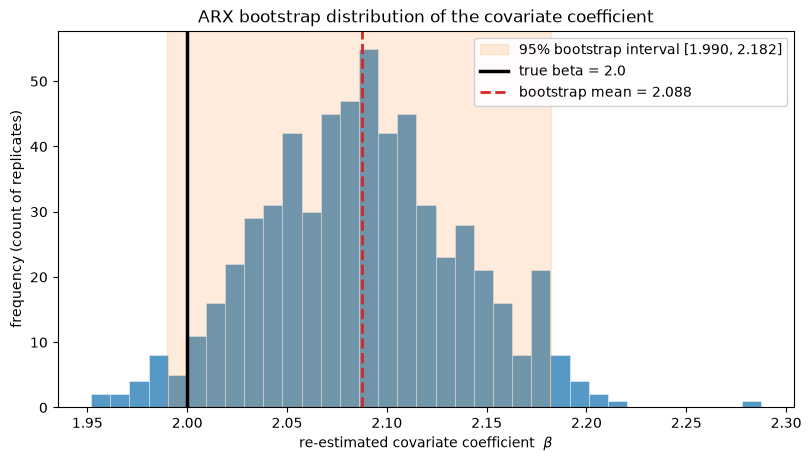

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax.hist(beta_draws, bins=35, color="tab:blue", alpha=0.75, edgecolor="white", linewidth=0.4)
ax.axvspan(
    lo, hi, color="tab:orange", alpha=0.15, label=f"95% bootstrap interval [{lo:.3f}, {hi:.3f}]"
)
ax.axvline(BETA, color="black", lw=2.5, label=f"true beta = {BETA}")
ax.axvline(
    beta_draws.mean(),
    color="tab:red",
    lw=2,
    ls="--",
    label=f"bootstrap mean = {beta_draws.mean():.3f}",
)
ax.set_xlabel(r"re-estimated covariate coefficient  $\beta$")
ax.set_ylabel("frequency (count of replicates)")
ax.set_title("ARX bootstrap distribution of the covariate coefficient")
ax.legend(loc="upper right", framealpha=0.9)
plt.show()

In [6]:
import pandas as pd

# Recovered-vs-true summary for the ARX covariate coefficient.
arx_table = pd.DataFrame(
    {
        "true": [BETA],
        "bootstrap mean": [beta_draws.mean()],
        "bootstrap std": [beta_draws.std()],
        "95% lower": [lo],
        "95% upper": [hi],
        "covers true": [bool(lo <= BETA <= hi)],
    },
    index=["beta"],
).round(4)
arx_table

,true,bootstrap mean,bootstrap std,95% lower,95% upper,covers true
beta,2.0,2.0876,0.0498,1.9899,2.1824,True


The distribution is centered on the true `beta = 2.0` and the 95% bootstrap interval brackets it. The covariate was held fixed across replicates, so this spread reflects only the innovation resampling, which is the uncertainty in `beta` given the observed `z`.

## VARX: a multivariate covariate effect

The same idea extends to a vector AR. We generate a bivariate VAR(1) driven by a single scalar covariate `z` with a known loading vector `B = [1.5, -0.8]`:

`Y_t = A Y_{t-1} + B z_t + e_t`.

We bootstrap with `exog=z` and refit the covariate loading on each replicate, one number per output series.

In [7]:
rng = np.random.default_rng(2)
n_varx = 400
A_true = np.array([[0.5, 0.1], [0.0, 0.4]])
B_true = np.array([1.5, -0.8])

zv = rng.standard_normal(n_varx)
ev = rng.standard_normal((n_varx, 2))
Y = np.zeros((n_varx, 2))
for t in range(1, n_varx):
    Y[t] = A_true @ Y[t - 1] + B_true * zv[t] + ev[t]

fit_v = fit_var(Y, 1, zv)
print("observed B hat:", np.round(fit_v.exog_coefs.ravel(), 4), " (true", B_true, ")")

observed B hat: [ 1.464  -0.8921]  (true [ 1.5 -0.8] )


In [8]:
varx_spec = ResidualBootstrap(model=VAR(order=1, initial="fixed", burn_in=0))
varx_res = bootstrap(Y, method=varx_spec, n_bootstraps=500, random_state=3, exog=zv)

# exog_coefs has shape (k, d) = (1, 2); ravel to the two per-series loadings.
B_draws = np.array([refit_var_beta(v, zv).ravel() for v in varx_res.values()])
for j in range(2):
    lo_j, hi_j = np.quantile(B_draws[:, j], [0.025, 0.975])
    print(
        f"series {j}: boot mean {B_draws[:, j].mean():+.4f}  true {B_true[j]:+.1f}  "
        f"95% [{lo_j:+.4f}, {hi_j:+.4f}]"
    )

series 0: boot mean +1.4631  true +1.5  95% [+1.3693, +1.5646]
series 1: boot mean -0.8916  true -0.8  95% [-0.9920, -0.7998]


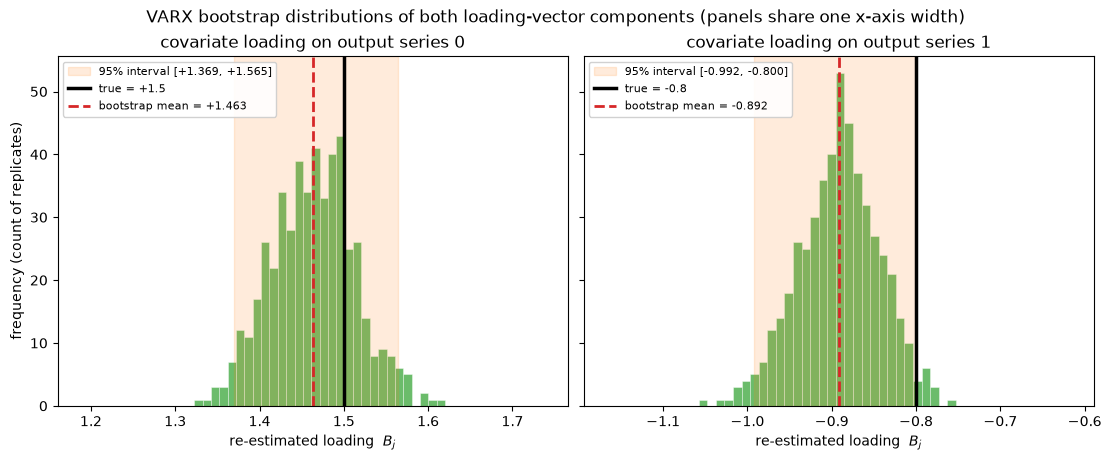

In [9]:
# Each loading sits at a different level (+1.5 vs -0.8), so center each panel on its
# own coefficient but give both panels the SAME x-axis WIDTH, so the recovered spreads
# are read on one comparable scale.
half_width = 0.5 * max(np.ptp(B_draws[:, j]) for j in range(2)) + 0.15

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True, constrained_layout=True)
for j, ax in enumerate(axes):
    lo_j, hi_j = np.quantile(B_draws[:, j], [0.025, 0.975])
    center = B_draws[:, j].mean()
    ax.hist(B_draws[:, j], bins=30, color="tab:green", alpha=0.7, edgecolor="white", linewidth=0.4)
    ax.axvspan(
        lo_j, hi_j, color="tab:orange", alpha=0.15, label=f"95% interval [{lo_j:+.3f}, {hi_j:+.3f}]"
    )
    ax.axvline(B_true[j], color="black", lw=2.5, label=f"true = {B_true[j]:+.1f}")
    ax.axvline(center, color="tab:red", lw=2, ls="--", label=f"bootstrap mean = {center:+.3f}")
    ax.set_title(f"covariate loading on output series {j}")
    ax.set_xlabel(r"re-estimated loading  $B_j$")
    ax.set_xlim(center - half_width, center + half_width)
    ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
axes[0].set_ylabel("frequency (count of replicates)")
fig.suptitle(
    "VARX bootstrap distributions of both loading-vector components (panels share one x-axis width)"
)
plt.show()

In [10]:
# Recovered-vs-true summary for both components of the loading vector B.
_rows = []
for j in range(2):
    lo_j, hi_j = np.quantile(B_draws[:, j], [0.025, 0.975])
    _rows.append(
        {
            "true": B_true[j],
            "bootstrap mean": B_draws[:, j].mean(),
            "bootstrap std": B_draws[:, j].std(),
            "95% lower": lo_j,
            "95% upper": hi_j,
            "covers true": bool(lo_j <= B_true[j] <= hi_j),
        }
    )
varx_table = pd.DataFrame(_rows, index=["B[0]", "B[1]"]).round(4)
varx_table

,true,bootstrap mean,bootstrap std,95% lower,95% upper,covers true
B[0],1.5,1.4631,0.0497,1.3693,1.5646,True
B[1],-0.8,-0.8916,0.0481,-0.9920,-0.7998,True


Both components of `B` are recovered: the positive loading on series 0 and the negative loading on series 1. The covariate enters the vector recursion at each step, which is why VARX inherits the same `initial="fixed"`, `burn_in=0` requirement as ARX.

## ARIMAX: a covariate on a trending series

Real macro series usually trend, so a stationary AR is the wrong model. ARIMAX differences the series to stationarity, fits an ARMA to the differenced part, and lets the covariate enter at the level. We use the statsmodels `macrodata` set: real GDP (a strongly trending series) as the target, and the consumer price index as the covariate.

This path needs statsmodels for the MA / MLE fit, which ships in the `[models]` extra (`pip install "tsbootstrap[models]"`). The `[examples]` extra used by the install cell already includes it.

In [11]:
from statsmodels.datasets import macrodata

macro = macrodata.load_pandas().data
gdp = macro["realgdp"].to_numpy()
cpi = macro["cpi"].to_numpy()
print(f"realgdp: {len(gdp)} quarters, ranges {gdp.min():.0f} to {gdp.max():.0f} (clearly trending)")
print(f"cpi    : ranges {cpi.min():.1f} to {cpi.max():.1f}")

realgdp: 203 quarters, ranges 2710 to 13415 (clearly trending)
cpi    : ranges 29.0 to 218.6


ARIMAX takes no `initial` or `burn_in` argument: it conditions on the observed initial differenced state, and integration would turn any burn-in transient into a permanent level shift, so those knobs would be incoherent. We just pass the order `(p, d, q)` and the covariate. With `d=1` the series is differenced once before the ARMA fit.

replicates shape: (300, 203)  (n_bootstraps, n_quarters)


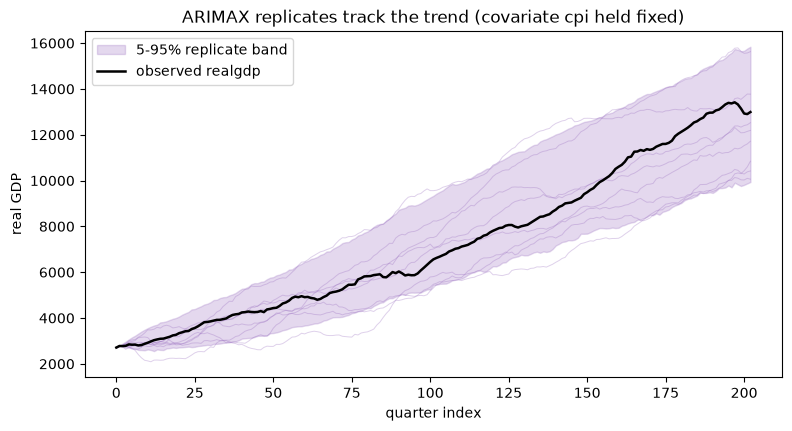

In [12]:
arimax_spec = ResidualBootstrap(model=ARIMA(order=(1, 1, 1)))
arimax_res = bootstrap(gdp, method=arimax_spec, n_bootstraps=300, random_state=4, exog=cpi)

samples = arimax_res.values()
print(f"replicates shape: {samples.shape}  (n_bootstraps, n_quarters)")

band_lo, band_hi = np.quantile(samples, [0.05, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(
    range(len(gdp)), band_lo, band_hi, color="tab:purple", alpha=0.25, label="5-95% replicate band"
)
for i in range(8):
    ax.plot(samples[i], color="tab:purple", alpha=0.3, lw=0.7)
ax.plot(gdp, color="black", lw=1.8, label="observed realgdp")
ax.set_xlabel("quarter index")
ax.set_ylabel("real GDP")
ax.set_title("ARIMAX replicates track the trend (covariate cpi held fixed)")
ax.legend()
plt.show()

The replicates follow the trend rather than collapsing to a stationary band, because the integration step rebuilds the level and the held-fixed covariate carries its part of the level back in. The covariate effect is estimated jointly with the ARMA part during the one-time fit and held fixed thereafter.

## When `exog` is rejected: a non-model method

Passing `exog` to a block method or `IID` is a configuration error, not a silent no-op. `tsbootstrap` raises a structured `MethodConfigError` so the mistake surfaces immediately. Here is what that looks like.

In [13]:
from tsbootstrap.errors import MethodConfigError

try:
    bootstrap(gdp, method=MovingBlock(block_length=10), n_bootstraps=10, exog=cpi)
except MethodConfigError as exc:
    print("raised:", type(exc).__name__)
    print(exc)

raised: MethodConfigError
[TSB_UNSUPPORTED_EXOG] exogenous regressors are only supported for model-based methods (ResidualBootstrap, SieveAR)


The error names which methods accept a covariate. The alignment constraints are enforced the same way: an ARX or VARX with `initial="random_block"` or `burn_in > 0` and a covariate also raises a `MethodConfigError`, because a random initial block or burn-in steps would break the time alignment between the covariate and the generated path.

In [14]:
# The two ARX alignment violations, each raised explicitly.
for bad_model, label in [
    (AR(order=1, initial="random_block"), 'initial="random_block"'),
    (AR(order=1, initial="fixed", burn_in=5), "burn_in=5"),
]:
    try:
        bootstrap(y, method=ResidualBootstrap(model=bad_model), n_bootstraps=5, exog=z)
    except MethodConfigError as exc:
        print(f"{label:24s} -> {exc}")

initial="random_block"   -> [TSB_UNSUPPORTED_EXOG] exogenous regressors require initial='fixed' (a random initial block would break the exog time alignment)
burn_in=5                -> [TSB_UNSUPPORTED_EXOG] exogenous regressors require burn_in=0 (there is no exog for burn-in steps)


## Working with covariates: the rules

- `exog` is accepted only by `ResidualBootstrap` (AR, VAR, ARIMA) and `SieveAR`; other methods raise `MethodConfigError`.
- The covariate is held fixed across replicates; only the model innovations are resampled, so the bootstrap spread is the uncertainty in the model given the observed covariate.
- ARX and VARX step through time, so they require `initial="fixed"` and `burn_in=0`. ARIMAX adds the covariate at the level and has no such constraint.
- Across all three shapes the bootstrap distribution recovers the known coefficient, which is the check that the covariate is being handled correctly rather than just accepted.